In [1]:
import platform
platform.platform()

'macOS-15.6.1-arm64-arm-64bit'

In [2]:
import sys
sys.version

'3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]'

In [3]:
import matplotlib
matplotlib.__version__

'3.10.8'

In [4]:
import matplotlib.pyplot as plt

In [5]:
import pandas as pd
pd.__version__

'2.3.3'

In [6]:
import seaborn as sns
sns.__version__

'0.13.2'

In [7]:
df_ecfp_onbits = pd.read_csv("../1_ECFP_OnBits/ecfp_OnBits.csv",
                             index_col=0)
df_ecfp_onbits

,Number,ECFP OnBits
Condition,,
K3FeCN6,23,117
MesAcr+BF4-,20,124
CuCl,19,102
Diacetyl,12,77
T(p-OMe)PPCo,9,77
Electrode,9,87
AllPhenols,4665,1984


In [8]:
df_ecfp_tanimoto = pd.read_csv("../2_ECFP_Tanimoto/ecfp_tanimoto.csv",
                               usecols=["Condition",
                                        "ECFP Tanimoto_avg", "ECFP Tanimoto_max"],
                               index_col=0)
df_ecfp_tanimoto

,ECFP Tanimoto_avg,ECFP Tanimoto_max
Condition,,
K3FeCN6,0.662146,0.857143
MesAcr+BF4-,0.678580,0.870968
CuCl,0.504993,0.704545
Diacetyl,0.650573,0.833333
T(p-OMe)PPCo,0.706042,0.868421
Electrode,0.658166,0.840909
AllPhenols,0.828374,0.954023


In [9]:
df_ecfp_convexhull = pd.read_csv("../3_ECFP_ConvexHull/ecfp_ConvexHull.csv",
                                 usecols=["Condition", "ECFP ConvexHull"],
                                 index_col=0)
df_ecfp_convexhull

,ECFP ConvexHull
Condition,
K3FeCN6,5.269410
MesAcr+BF4-,3.868490
CuCl,3.333184
Diacetyl,3.332658
T(p-OMe)PPCo,5.920380
Electrode,3.562639
AllPhenols,15.178196


In [10]:
df_range = pd.read_csv("../4_Range/range.csv",
                       usecols=["Condition", "Range"],
                       index_col=0)
df_range

,Range
Condition,
K3FeCN6,36.228329
MesAcr+BF4-,52.504632
CuCl,34.148565
Diacetyl,28.231906
T(p-OMe)PPCo,26.795494
Electrode,35.016545
AllPhenols,234.098189


In [11]:
df_distance = pd.read_csv("../5_Distance/distance.csv",
                          usecols=["Condition", "Distance_avg", "Distance_max"],
                          index_col=0)
df_distance

,Distance_avg,Distance_max
Condition,,
K3FeCN6,2.816789,5.054441
MesAcr+BF4-,3.464991,5.727723
CuCl,2.245464,5.722111
Diacetyl,2.776980,3.409037
T(p-OMe)PPCo,2.927570,4.446373
Electrode,2.880096,4.962116
AllPhenols,5.006336,18.215869


In [12]:
df_convexhull = pd.read_csv("../6_ConvexHull/ConvexHull.csv",
                            usecols=["Condition", "ConvexHull"],
                            index_col=0)
df_convexhull

,ConvexHull
Condition,
K3FeCN6,4.143509
MesAcr+BF4-,6.430957
CuCl,3.515904
Diacetyl,4.459198
T(p-OMe)PPCo,3.220795
Electrode,3.629311
AllPhenols,17.989857


In [13]:
df_all = pd.concat([df_ecfp_onbits, df_ecfp_tanimoto, df_ecfp_convexhull,
                    df_range, df_distance, df_convexhull],
                    axis=1)
df_all

,Number,ECFP OnBits,ECFP Tanimoto_avg,ECFP Tanimoto_max,ECFP ConvexHull,Range,Distance_avg,Distance_max,ConvexHull
Condition,,,,,,,,,
K3FeCN6,23,117,0.662146,0.857143,5.269410,36.228329,2.816789,5.054441,4.143509
MesAcr+BF4-,20,124,0.678580,0.870968,3.868490,52.504632,3.464991,5.727723,6.430957
CuCl,19,102,0.504993,0.704545,3.333184,34.148565,2.245464,5.722111,3.515904
Diacetyl,12,77,0.650573,0.833333,3.332658,28.231906,2.776980,3.409037,4.459198
T(p-OMe)PPCo,9,77,0.706042,0.868421,5.920380,26.795494,2.927570,4.446373,3.220795
Electrode,9,87,0.658166,0.840909,3.562639,35.016545,2.880096,4.962116,3.629311
AllPhenols,4665,1984,0.828374,0.954023,15.178196,234.098189,5.006336,18.215869,17.989857


In [14]:
for i in range(9):
    li = []
    for j in range(7):
        li.append(df_all.iat[j, i] / df_all.iat[6, i])
    df_all[f"Ratio_{df_all.columns[i]}"] = li

df_all

,Number,ECFP OnBits,ECFP Tanimoto_avg,ECFP Tanimoto_max,ECFP ConvexHull,Range,Distance_avg,Distance_max,ConvexHull,Ratio_Number,Ratio_ECFP OnBits,Ratio_ECFP Tanimoto_avg,Ratio_ECFP Tanimoto_max,Ratio_ECFP ConvexHull,Ratio_Range,Ratio_Distance_avg,Ratio_Distance_max,Ratio_ConvexHull
Condition,,,,,,,,,,,,,,,,,,
K3FeCN6,23,117,0.662146,0.857143,5.269410,36.228329,2.816789,5.054441,4.143509,0.004930,0.058972,0.799333,0.898451,0.347170,0.154757,0.562645,0.277475,0.230325
MesAcr+BF4-,20,124,0.678580,0.870968,3.868490,52.504632,3.464991,5.727723,6.430957,0.004287,0.062500,0.819171,0.912942,0.254872,0.224285,0.692121,0.314436,0.357477
CuCl,19,102,0.504993,0.704545,3.333184,34.148565,2.245464,5.722111,3.515904,0.004073,0.051411,0.609620,0.738499,0.219603,0.145873,0.448524,0.314128,0.195438
Diacetyl,12,77,0.650573,0.833333,3.332658,28.231906,2.776980,3.409037,4.459198,0.002572,0.038810,0.785362,0.873494,0.219569,0.120599,0.554693,0.187147,0.247873
T(p-OMe)PPCo,9,77,0.706042,0.868421,5.920380,26.795494,2.927570,4.446373,3.220795,0.001929,0.038810,0.852323,0.910273,0.390058,0.114463,0.584773,0.244093,0.179034
Electrode,9,87,0.658166,0.840909,3.562639,35.016545,2.880096,4.962116,3.629311,0.001929,0.043851,0.794527,0.881435,0.234721,0.149581,0.575290,0.272406,0.201742
AllPhenols,4665,1984,0.828374,0.954023,15.178196,234.098189,5.006336,18.215869,17.989857,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
df_all.to_csv("substrate_scope_summary.csv")

In [16]:
df_all = pd.read_csv("substrate_scope_summary.csv",
                  usecols=["Condition", "Number",
                           "Ratio_ECFP OnBits",
                           "Ratio_ECFP Tanimoto_avg", "Ratio_ECFP Tanimoto_max",
                           "Ratio_ECFP ConvexHull",
                           "Ratio_Range",
                           "Ratio_Distance_avg", "Ratio_Distance_max",
                           "Ratio_ConvexHull"])
df_all

,Condition,Number,Ratio_ECFP OnBits,Ratio_ECFP Tanimoto_avg,Ratio_ECFP Tanimoto_max,Ratio_ECFP ConvexHull,Ratio_Range,Ratio_Distance_avg,Ratio_Distance_max,Ratio_ConvexHull
0,K3FeCN6,23,0.058972,0.799333,0.898451,0.347170,0.154757,0.562645,0.277475,0.230325
1,MesAcr+BF4-,20,0.062500,0.819171,0.912942,0.254872,0.224285,0.692121,0.314436,0.357477
2,CuCl,19,0.051411,0.609620,0.738499,0.219603,0.145873,0.448524,0.314128,0.195438
3,Diacetyl,12,0.038810,0.785362,0.873494,0.219569,0.120599,0.554693,0.187147,0.247873
4,T(p-OMe)PPCo,9,0.038810,0.852323,0.910273,0.390058,0.114463,0.584773,0.244093,0.179034
5,Electrode,9,0.043851,0.794527,0.881435,0.234721,0.149581,0.575290,0.272406,0.201742
6,AllPhenols,4665,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
df_melt = pd.melt(df_all.iloc[:6], id_vars=["Condition", "Number"])
df_melt

,Condition,Number,variable,value
0,K3FeCN6,23,Ratio_ECFP OnBits,0.058972
1,MesAcr+BF4-,20,Ratio_ECFP OnBits,0.062500
2,CuCl,19,Ratio_ECFP OnBits,0.051411
3,Diacetyl,12,Ratio_ECFP OnBits,0.038810
4,T(p-OMe)PPCo,9,Ratio_ECFP OnBits,0.038810
5,Electrode,9,Ratio_ECFP OnBits,0.043851
6,K3FeCN6,23,Ratio_ECFP Tanimoto_avg,0.799333
7,MesAcr+BF4-,20,Ratio_ECFP Tanimoto_avg,0.819171
8,CuCl,19,Ratio_ECFP Tanimoto_avg,0.609620
9,Diacetyl,12,Ratio_ECFP Tanimoto_avg,0.785362


In [18]:
df_melt.shape

(48, 4)

In [19]:
conditions = [["K3FeCN6",(255/255, 75/255, 0/255), "K$_3$[Fe(CN)$_6$]"],
              ["MesAcr+BF4-", (153/255, 0/255, 153/255), "MesAcr$^+$BF$_4^-$"],
              ["CuCl", (3/255, 175/255, 122/255), "CuCl"],
              ["Diacetyl", (246/255, 170/255, 0/255), "Diacetyl"],
              ["T(p-OMe)PPCo", (77/255, 196/255, 255/255), "T($p$-OMe)PPCo"],
              ["Electrode", (255/255, 128/255, 130/255), "Electrode"]]

In [20]:
labels = []

for i in range(6):
    labels.append(f"{conditions[i][2]} ({df_all.at[i, 'Number']})")
    
labels

['K$_3$[Fe(CN)$_6$] (23)',
 'MesAcr$^+$BF$_4^-$ (20)',
 'CuCl (19)',
 'Diacetyl (12)',
 'T($p$-OMe)PPCo (9)',
 'Electrode (9)']

In [21]:
for i in range(6):
    df_melt.replace(conditions[i][0], labels[i], inplace=True)

df_melt.replace({"Ratio_ECFP OnBits": "ECFP OnBits",
                 "Ratio_ECFP Tanimoto_avg": "ECFP Tanimoto$_{\mathrm{avg}}$",
                 "Ratio_ECFP Tanimoto_max": "ECFP Tanimoto$_{\mathrm{max}}$",
                 "Ratio_ECFP ConvexHull": "ECFP ConvexHull",
                 "Ratio_Range": "Range",
                 "Ratio_Distance_avg": "Distance$_{\mathrm{avg}}$",
                 "Ratio_Distance_max": "Distance$_{\mathrm{max}}$",
                 "Ratio_ConvexHull": "ConvexHull"},
                 inplace=True)

df_melt["Coverage"] = df_melt["value"] * 100

df_melt.rename(columns={"variable": "Indicator"}, inplace=True)
df_melt.drop("Number", axis=1, inplace=True)
df_melt.drop("value", axis=1, inplace=True)

df_melt

,Condition,Indicator,Coverage
0,K$_3$[Fe(CN)$_6$] (23),ECFP OnBits,5.897177
1,MesAcr$^+$BF$_4^-$ (20),ECFP OnBits,6.250000
2,CuCl (19),ECFP OnBits,5.141129
3,Diacetyl (12),ECFP OnBits,3.881048
4,T($p$-OMe)PPCo (9),ECFP OnBits,3.881048
5,Electrode (9),ECFP OnBits,4.385081
6,K$_3$[Fe(CN)$_6$] (23),ECFP Tanimoto$_{\mathrm{avg}}$,79.933276
7,MesAcr$^+$BF$_4^-$ (20),ECFP Tanimoto$_{\mathrm{avg}}$,81.917090
8,CuCl (19),ECFP Tanimoto$_{\mathrm{avg}}$,60.962038
9,Diacetyl (12),ECFP Tanimoto$_{\mathrm{avg}}$,78.536164


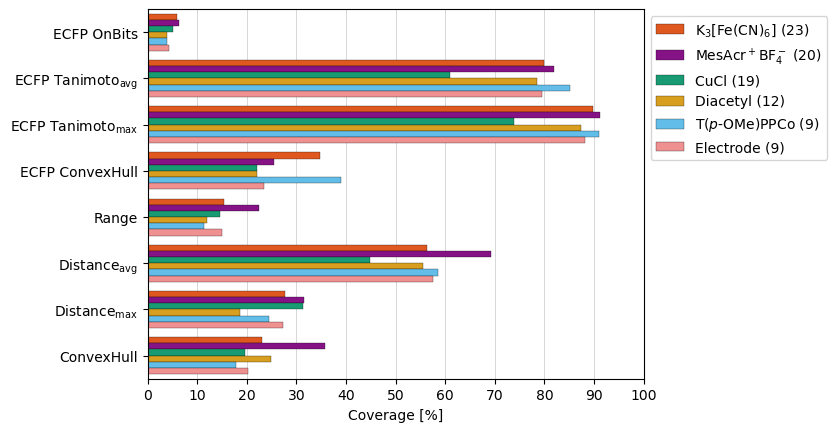

In [22]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

sns.barplot(data=df_melt,
            x="Coverage",
            y="Indicator",
            hue="Condition",
            hue_order=labels,
            palette=[e[1] for e in conditions],
            linewidth=0.2,
            edgecolor="k")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel("Coverage [%]")
ax.set_ylabel("")

ax.set_axisbelow(True)
ax.grid(True, axis="x", linewidth=0.5, color=(200/255, 200/255, 203/255))

plt.xticks([x * 10 for x in range(11)])

plt.savefig("substrate_scope_summary.png", dpi=300, bbox_inches="tight")
plt.show()